In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np



In [84]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

In [88]:
model = Sequential()
model.add(InputLayer(input_shape=(2,)))
model.add(Dense(5, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

In [89]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [90]:
history = model.fit(X, y, epochs=2000, batch_size=1, verbose=0)

In [91]:
loss, accuracy = model.evaluate(X, y, verbose=0)
print('Accuracy: {:.2f}'.format(accuracy*100))

Accuracy: 100.00


In [92]:
for id_x, data_sample in enumerate(X):
  data_sample = np.array(data_sample).reshape(1,-1)
  prediction = model.predict([data_sample])
  print(f"Data sample is {data_sample}, prediction from model {prediction}, ground_truth {y[id_x]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Data sample is [[0 0]], prediction from model [[0.0029163]], ground_truth 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Data sample is [[0 1]], prediction from model [[0.99416494]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_44
Received: inputs=('Tensor(shape=(1, 2))',)
  warnings.warn(msg)


Data sample is [[1 0]], prediction from model [[0.99243605]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Data sample is [[1 1]], prediction from model [[0.00702275]], ground_truth 0


Text(0, 0.5, 'loss')

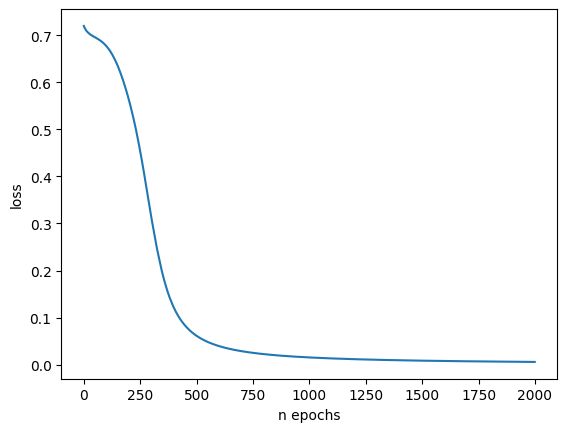

In [93]:
plt.figure()
plt.plot(history.history['loss'])
plt.xlabel('n epochs')
plt.ylabel('loss')

In [94]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import matplotlib.pyplot as plt

In [95]:
path_to_dataset = 'source/voting_complete.csv' # change the PATH
pd_dataset = pd.read_csv(path_to_dataset)

In [202]:
def train_test_split(pd_data: pd.DataFrame, test_ratio: float = 0.2) -> tuple:
    pd_dataset = pd_data.copy()
    pd_dataset = pd_dataset[pd_dataset.columns[1:]]
    index = np.arange(len(pd_dataset))
    index = np.random.permutation(index)
    train_ammount = int(len(index)*test_ratio)
    train_ids = index[train_ammount:]
    test_ids = index[:train_ammount]

    train_dataset = pd_dataset[pd_dataset.index.isin(train_ids)].reset_index()
    test_dataset = pd_dataset[pd_dataset.index.isin(test_ids)].reset_index()

    train_dataset = train_dataset[train_dataset.columns[1:]]
    test_dataset = test_dataset[test_dataset.columns[1:]]

    return train_dataset[train_dataset.columns[1:]], train_dataset[train_dataset.columns[0]], test_dataset[test_dataset.columns[1:]], test_dataset[test_dataset.columns[0]]

In [203]:
X_train, y_train, X_test, y_test = train_test_split(pd_dataset)

In [204]:
X_train

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,n,n,y,n,n,n,y,y,n,y,y,n,n,n,y,?
344,y,n,y,n,?,n,y,y,y,y,n,y,n,?,y,y
345,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
346,n,n,n,y,y,y,?,?,?,?,n,y,y,y,n,y


In [205]:
def preprocess_data(X_train, y_train, X_test, y_test):

    X_train = pd.DataFrame(X_train).copy()
    X_test = pd.DataFrame(X_test).copy()
    y_train = pd.Series(y_train)
    y_test = pd.Series(y_test)

    mapping = {'y': 1, 'n': 0}

    for col in X_train.columns:

        # hodnoty bez '?'
        valid = X_train.loc[X_train[col] != '?', col]

        mode_vals = valid.mode()

        if not mode_vals.empty:
            most_common = mode_vals.iloc[0]
        else:
            most_common = 'n'  # fallback

        X_train[col] = X_train[col].replace('?', most_common)
        X_test[col] = X_test[col].replace('?', most_common)

        X_train[col] = X_train[col].map(mapping)
        X_test[col] = X_test[col].map(mapping)

    y_train = y_train.map({'republican': 1, 'democrat': 0})
    y_test = y_test.map({'republican': 1, 'democrat': 0})

    return X_train.values, y_train.values, X_test.values, y_test.values


In [206]:
X_train, y_train, X_test, y_test = preprocess_data(X_train, y_train, X_test, y_test)

In [207]:
y_test

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1])

In [250]:
model_rd = Sequential()
model_rd.add(InputLayer(input_shape=(16,)))
model_rd.add(Dense(20, activation='relu'))
model_rd.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [251]:
optimizer_rd = tf.keras.optimizers.SGD(learning_rate=0.1)
model_rd.summary()
model_rd.compile(loss='binary_crossentropy', optimizer=optimizer_rd, metrics=['accuracy'])

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 20)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [263]:
rd = model_rd.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    batch_size=30,
    verbose=0
)

In [264]:
loss, accuracy = model_rd.evaluate(X_train, y_train, verbose=0)
print(f'Accuracy: {accuracy*100:.2f} Loss: {loss*100:.2f}')

Accuracy: 99.71 Loss: 0.58


Text(0, 0.5, 'loss')

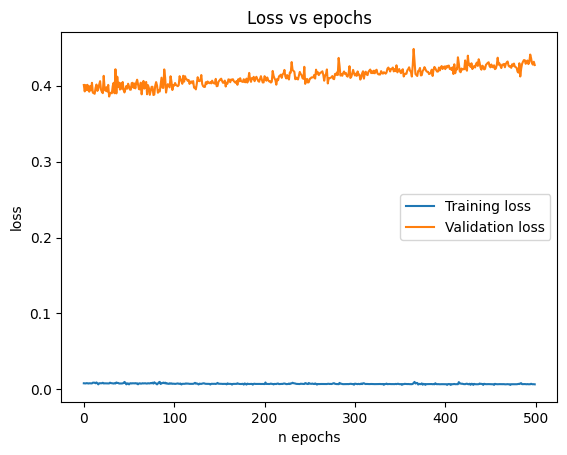

In [265]:
plt.figure()
plt.title('Loss vs epochs')
plt.plot(rd.history['loss'], label='Training loss')
plt.plot(rd.history['val_loss'], label='Validation loss')
plt.xlabel('n epochs')
plt.legend()
plt.ylabel('loss')

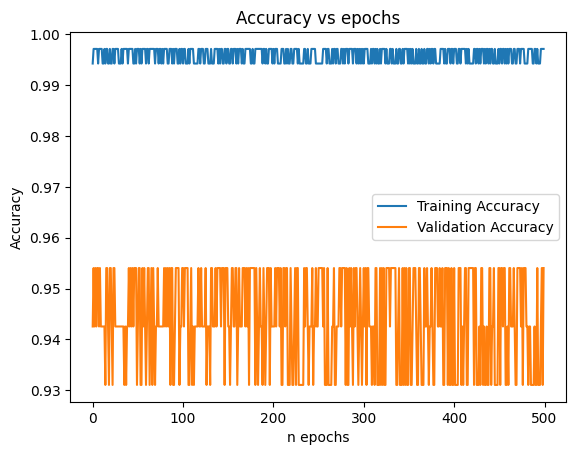

In [267]:
plt.figure()
plt.plot(rd.history['accuracy'], label='Training Accuracy')
plt.plot(rd.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('n epochs')
plt.title('Accuracy vs epochs')
plt.legend()
plt.show()